In [ ]:
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete.")

Setup complete.


In [ ]:
BASE_DIR = Path("/content")

INDOMAIN_ZIP = BASE_DIR / "artifacts_small.zip"
LODO_ZIP = BASE_DIR / "lodo_small.zip"

INDOMAIN_DIR = BASE_DIR / "artifacts_small"
LODO_DIR = BASE_DIR / "lodo_small"

print("In-domain ZIP:", INDOMAIN_ZIP.exists())
print("LODO ZIP:", LODO_ZIP.exists())

In-domain ZIP: True
LODO ZIP: True


In [ ]:
with zipfile.ZipFile(INDOMAIN_ZIP, "r") as zip_ref:
    zip_ref.extractall(INDOMAIN_DIR)

with zipfile.ZipFile(LODO_ZIP, "r") as zip_ref:
    zip_ref.extractall(LODO_DIR)

print("Both ZIP files extracted successfully.")

Both ZIP files extracted successfully.


In [ ]:
indomain_metrics = sorted(INDOMAIN_DIR.rglob("metrics.json"))
lodo_metrics = sorted(LODO_DIR.rglob("metrics.json"))

print("In-domain runs found:", len(indomain_metrics))
print("LODO runs found:", len(lodo_metrics))

print("\nIn-domain:")
for path in indomain_metrics:
    print(path.relative_to(INDOMAIN_DIR))

print("\nLODO:")
for path in lodo_metrics:
    print(path.relative_to(LODO_DIR))

In-domain runs found: 10
LODO runs found: 12

In-domain:
artifacts_small/artifacts/runs/indomain/standard/seed_123/metrics.json
artifacts_small/artifacts/runs/indomain/standard/seed_13/metrics.json
artifacts_small/artifacts/runs/indomain/standard/seed_2024/metrics.json
artifacts_small/artifacts/runs/indomain/standard/seed_42/metrics.json
artifacts_small/artifacts/runs/indomain/standard/seed_777/metrics.json
artifacts_small/artifacts/runs/indomain/weighted/seed_123/metrics.json
artifacts_small/artifacts/runs/indomain/weighted/seed_13/metrics.json
artifacts_small/artifacts/runs/indomain/weighted/seed_2024/metrics.json
artifacts_small/artifacts/runs/indomain/weighted/seed_42/metrics.json
artifacts_small/artifacts/runs/indomain/weighted/seed_777/metrics.json

LODO:
lodo_small/coursera/standard/seed_13/metrics.json
lodo_small/coursera/weighted/seed_13/metrics.json
lodo_small/food/standard/seed_13/metrics.json
lodo_small/food/weighted/seed_13/metrics.json
lodo_small/hotel/standard/seed_13/me

In [ ]:
with open(indomain_metrics[0], "r") as f:
    sample_metrics = json.load(f)

print("Top-level keys:")
print(sample_metrics.keys())

Top-level keys:
dict_keys(['dev', 'schema_version', 'selection', 'summary', 'task_scope', 'test'])


In [ ]:
for key, value in sample_metrics.items():
    print(f"\n--- {key} ---")

    if isinstance(value, dict):
        print("Keys:", value.keys())
    else:
        print("Type:", type(value))


--- dev ---
Keys: dict_keys(['category_by_label', 'complete_triplet', 'error_analysis', 'loss', 'num_examples', 'per_domain', 'rare_category_labels', 'rare_category_recall', 'sentiment_by_label'])

--- schema_version ---
Type: <class 'int'>

--- selection ---
Keys: dict_keys(['best_epoch', 'best_epoch_dev', 'metric'])

--- summary ---
Keys: dict_keys(['artifact_dir', 'best_dev_micro_f1', 'best_epoch', 'completed_at', 'config', 'dev_loss', 'dev_macro_f1', 'dev_micro_f1', 'dev_micro_precision', 'dev_micro_recall', 'dev_rare_category_recall', 'dev_size', 'device', 'mode', 'schema_version', 'seed', 'selection_metric', 'status', 'task_scope', 'test_loss', 'test_macro_f1', 'test_micro_f1', 'test_micro_precision', 'test_micro_recall', 'test_rare_category_recall', 'test_size', 'train_size', 'trainable_params', 'training_time_sec'])

--- task_scope ---
Type: <class 'str'>

--- test ---
Keys: dict_keys(['category_by_label', 'complete_triplet', 'error_analysis', 'loss', 'num_examples', 'per_doma

In [ ]:
complete_triplet = sample_metrics["test"]["complete_triplet"]

print(complete_triplet)

{'false_negatives': 2781, 'false_positives': 2076, 'macro_f1': 0.09367970518062008, 'micro_f1': 0.36301639344262293, 'micro_precision': 0.4, 'micro_recall': 0.33229291716686676, 'true_positives': 1384}


In [ ]:
existing_error_analysis = sample_metrics["test"]["error_analysis"]

print(existing_error_analysis)

{'by_domain': {'coursera': {'aspect_missed': 132, 'category_wrong': 74, 'extra_predicted': 149, 'sentiment_wrong': 24}, 'food': {'aspect_missed': 194, 'category_wrong': 29, 'extra_predicted': 53, 'sentiment_wrong': 7}, 'hotel': {'aspect_missed': 156, 'category_wrong': 94, 'extra_predicted': 195, 'sentiment_wrong': 16}, 'laptop': {'aspect_missed': 261, 'category_wrong': 159, 'extra_predicted': 344, 'sentiment_wrong': 25}, 'phone': {'aspect_missed': 770, 'category_wrong': 68, 'extra_predicted': 405, 'sentiment_wrong': 9}, 'restaurant': {'aspect_missed': 211, 'category_wrong': 48, 'extra_predicted': 227, 'sentiment_wrong': 29}, 'sight': {'aspect_missed': 479, 'category_wrong': 20, 'extra_predicted': 118, 'sentiment_wrong': 20}}, 'overall': {'aspect_missed': 2203, 'category_wrong': 492, 'extra_predicted': 1491, 'sentiment_wrong': 130}}


In [ ]:
per_domain = sample_metrics["test"]["per_domain"]

print("Domains available:")
print(per_domain.keys())

Domains available:
dict_keys(['coursera', 'food', 'hotel', 'laptop', 'phone', 'restaurant', 'sight'])


In [ ]:
def read_run(metrics_path, setting, model, seed, held_out_domain=None):
    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    triplet = metrics["test"]["complete_triplet"]

    return {
        "setting": setting,
        "held_out_domain": held_out_domain,
        "model": model,
        "seed": seed,
        "precision": triplet["micro_precision"],
        "recall": triplet["micro_recall"],
        "f1": triplet["micro_f1"],
        "true_positives": triplet["true_positives"],
        "false_positives": triplet["false_positives"],
        "false_negatives": triplet["false_negatives"]
    }

In [ ]:
rows = []

for path in indomain_metrics:
    parts = path.parts

    model = path.parent.parent.name
    seed = int(path.parent.name.replace("seed_", ""))

    row = read_run(
        metrics_path=path,
        setting="In-domain",
        model=model,
        seed=seed,
        held_out_domain=None
    )

    rows.append(row)

print("In-domain rows collected:", len(rows))

In-domain rows collected: 10


In [ ]:
for path in lodo_metrics:
    model = path.parent.parent.name
    held_out_domain = path.parent.parent.parent.name
    seed = int(path.parent.name.replace("seed_", ""))

    row = read_run(
        metrics_path=path,
        setting="LODO",
        model=model,
        seed=seed,
        held_out_domain=held_out_domain
    )

    rows.append(row)

print("Total rows collected:", len(rows))

Total rows collected: 22


In [ ]:
results_df = pd.DataFrame(rows)

results_df

,setting,held_out_domain,model,seed,precision,recall,f1,true_positives,false_positives,false_negatives
0,In-domain,None,standard,123,0.400000,0.332293,0.363016,1384,2076,2781
1,In-domain,None,standard,13,0.381241,0.317167,0.346265,1321,2144,2844
2,In-domain,None,standard,2024,0.391103,0.303962,0.342070,1266,1971,2899
3,In-domain,None,standard,42,0.392007,0.320288,0.352537,1334,2069,2831
4,In-domain,None,standard,777,0.385303,0.331092,0.356147,1379,2200,2786
5,In-domain,None,weighted,123,0.188592,0.422329,0.260747,1759,7568,2406
6,In-domain,None,weighted,13,0.188685,0.427611,0.261835,1781,7658,2384
7,In-domain,None,weighted,2024,0.197149,0.424970,0.269345,1770,7208,2395
8,In-domain,None,weighted,42,0.195770,0.424490,0.267960,1768,7263,2397
9,In-domain,None,weighted,777,0.184298,0.428331,0.257710,1784,7896,2381


In [ ]:
indomain_df = results_df[results_df["setting"] == "In-domain"]

indomain_summary = (
    indomain_df
    .groupby("model")[["precision", "recall", "f1"]]
    .agg(["mean", "std"])
    .round(4)
)

indomain_summary

precision          recall              f1        
              mean     std    mean     std    mean     std
model                                                     
standard    0.3899  0.0071  0.3210  0.0116  0.3520  0.0082
weighted    0.1909  0.0054  0.4255  0.0024  0.2635  0.0049

In [ ]:
indomain_counts = (
    indomain_df
    .groupby("model")[
        ["true_positives", "false_positives", "false_negatives"]
    ]
    .mean()
    .round(1)
)

indomain_counts

,true_positives,false_positives,false_negatives
model,,,
standard,1336.8,2092.0,2828.2
weighted,1772.4,7518.6,2392.6


In [16]:
standard = (
    indomain_df[indomain_df["model"] == "standard"]
    .set_index("seed")
)

weighted = (
    indomain_df[indomain_df["model"] == "weighted"]
    .set_index("seed")
)

seed_comparison = pd.DataFrame({
    "standard_precision": standard["precision"],
    "weighted_precision": weighted["precision"],
    "precision_change": weighted["precision"] - standard["precision"],

    "standard_recall": standard["recall"],
    "weighted_recall": weighted["recall"],
    "recall_change": weighted["recall"] - standard["recall"],

    "standard_f1": standard["f1"],
    "weighted_f1": weighted["f1"],
    "f1_change": weighted["f1"] - standard["f1"]
}).round(4)

seed_comparison

,standard_precision,weighted_precision,precision_change,standard_recall,weighted_recall,recall_change,standard_f1,weighted_f1,f1_change
seed,,,,,,,,,
123,0.4000,0.1886,-0.2114,0.3323,0.4223,0.0900,0.3630,0.2607,-0.1023
13,0.3812,0.1887,-0.1926,0.3172,0.4276,0.1104,0.3463,0.2618,-0.0844
2024,0.3911,0.1971,-0.1940,0.3040,0.4250,0.1210,0.3421,0.2693,-0.0727
42,0.3920,0.1958,-0.1962,0.3203,0.4245,0.1042,0.3525,0.2680,-0.0846
777,0.3853,0.1843,-0.2010,0.3311,0.4283,0.0972,0.3561,0.2577,-0.0984


In [17]:
print("Weighted recall higher in:",
      (seed_comparison["recall_change"] > 0).sum(),
      "out of",
      len(seed_comparison),
      "matched seeds")

print("Weighted precision higher in:",
      (seed_comparison["precision_change"] > 0).sum(),
      "out of",
      len(seed_comparison),
      "matched seeds")

print("Weighted F1 higher in:",
      (seed_comparison["f1_change"] > 0).sum(),
      "out of",
      len(seed_comparison),
      "matched seeds")

Weighted recall higher in: 5 out of 5 matched seeds
Weighted precision higher in: 0 out of 5 matched seeds
Weighted F1 higher in: 0 out of 5 matched seeds


In [18]:
sample_errors = sample_metrics["test"]["error_analysis"]["by_domain"]

for domain, errors in sample_errors.items():
    print(domain, ":", errors)

coursera : {'aspect_missed': 132, 'category_wrong': 74, 'extra_predicted': 149, 'sentiment_wrong': 24}
food : {'aspect_missed': 194, 'category_wrong': 29, 'extra_predicted': 53, 'sentiment_wrong': 7}
hotel : {'aspect_missed': 156, 'category_wrong': 94, 'extra_predicted': 195, 'sentiment_wrong': 16}
laptop : {'aspect_missed': 261, 'category_wrong': 159, 'extra_predicted': 344, 'sentiment_wrong': 25}
phone : {'aspect_missed': 770, 'category_wrong': 68, 'extra_predicted': 405, 'sentiment_wrong': 9}
restaurant : {'aspect_missed': 211, 'category_wrong': 48, 'extra_predicted': 227, 'sentiment_wrong': 29}
sight : {'aspect_missed': 479, 'category_wrong': 20, 'extra_predicted': 118, 'sentiment_wrong': 20}


In [19]:
print("Error analysis keys:")
print(sample_metrics["test"]["error_analysis"].keys())

Error analysis keys:
dict_keys(['by_domain', 'overall'])


In [20]:
sample_overall_errors = sample_metrics["test"]["error_analysis"]["overall"]

print(sample_overall_errors)

{'aspect_missed': 2203, 'category_wrong': 492, 'extra_predicted': 1491, 'sentiment_wrong': 130}


In [21]:
error_rows = []

for path in indomain_metrics:
    model = path.parent.parent.name
    seed = int(path.parent.name.replace("seed_", ""))

    with open(path, "r") as f:
        metrics = json.load(f)

    errors = metrics["test"]["error_analysis"]["overall"]

    error_rows.append({
        "model": model,
        "seed": seed,
        "aspect_missed": errors["aspect_missed"],
        "category_wrong": errors["category_wrong"],
        "sentiment_wrong": errors["sentiment_wrong"],
        "extra_predicted": errors["extra_predicted"]
    })

errors_df = pd.DataFrame(error_rows)

errors_df

,model,seed,aspect_missed,category_wrong,sentiment_wrong,extra_predicted
0,standard,123,2203,492,130,1491
1,standard,13,2290,478,111,1586
2,standard,2024,2397,438,96,1463
3,standard,42,2289,465,108,1523
4,standard,777,2240,465,119,1644
5,weighted,123,990,1228,371,6085
6,weighted,13,1008,1180,362,6224
7,weighted,2024,1020,1181,354,5782
8,weighted,42,1026,1197,346,5840
9,weighted,777,990,1196,369,6429


In [22]:
error_summary = (
    errors_df
    .groupby("model")[
        ["aspect_missed", "category_wrong",
         "sentiment_wrong", "extra_predicted"]
    ]
    .mean()
    .round(1)
)

error_summary

,aspect_missed,category_wrong,sentiment_wrong,extra_predicted
model,,,,
standard,2283.8,467.6,112.8,1541.4
weighted,1006.8,1196.4,360.4,6072.0


In [23]:
error_change = (
    error_summary.loc["weighted"]
    - error_summary.loc["standard"]
)

error_change.name = "weighted_minus_standard"

error_change

,weighted_minus_standard
aspect_missed,-1277.0
category_wrong,728.8
sentiment_wrong,247.6
extra_predicted,4530.6


In [24]:
domain_error_rows = []

for path in indomain_metrics:
    model = path.parent.parent.name
    seed = int(path.parent.name.replace("seed_", ""))

    with open(path, "r") as f:
        metrics = json.load(f)

    by_domain = metrics["test"]["error_analysis"]["by_domain"]

    for domain, errors in by_domain.items():
        domain_error_rows.append({
            "model": model,
            "seed": seed,
            "domain": domain,
            "aspect_missed": errors["aspect_missed"],
            "category_wrong": errors["category_wrong"],
            "sentiment_wrong": errors["sentiment_wrong"],
            "extra_predicted": errors["extra_predicted"]
        })

domain_errors_df = pd.DataFrame(domain_error_rows)

print("Rows:", len(domain_errors_df))
domain_errors_df.head(10)

Rows: 70


,model,seed,domain,aspect_missed,category_wrong,sentiment_wrong,extra_predicted
0,standard,123,coursera,132,74,24,149
1,standard,123,food,194,29,7,53
2,standard,123,hotel,156,94,16,195
3,standard,123,laptop,261,159,25,344
4,standard,123,phone,770,68,9,405
5,standard,123,restaurant,211,48,29,227
6,standard,123,sight,479,20,20,118
7,standard,13,coursera,162,62,17,152
8,standard,13,food,198,25,2,62
9,standard,13,hotel,151,105,17,237


In [25]:
domain_error_summary = (
    domain_errors_df
    .groupby(["domain", "model"])[
        ["aspect_missed", "category_wrong",
         "sentiment_wrong", "extra_predicted"]
    ]
    .mean()
    .round(1)
)

domain_error_summary

aspect_missed  category_wrong  sentiment_wrong  \
domain     model                                                      
coursera   standard          142.4            68.4             19.8   
           weighted           55.4           154.2             42.0   
food       standard          203.6            24.4              3.2   
           weighted           48.0           108.4             39.4   
hotel      standard          167.0            89.6             13.4   
           weighted           65.4           156.2             28.4   
laptop     standard          256.2           161.6             24.0   
           weighted           75.2           283.2             61.4   
phone      standard          787.4            68.6             12.0   
           weighted          470.6           225.4             51.6   
restaurant standard          249.4            32.2             21.6   
           weighted           79.0           123.4             46.2   
sight      standard          477.8            22.8             18.8   
           weighted          213.2           145.6             91.4   

                     extra_predicted  
domain     model                      
coursera   standard            144.4  
           weighted            530.0  
food       standard             59.4  
           weighted            508.0  
hotel      standard            225.0  
           weighted            614.4  
laptop     standard            325.6  
           weighted            568.6  
phone      standard            423.6  
           weighted           2443.2  
restaurant standard            243.6  
           weighted            467.8  
sight      standard            119.8  
           weighted            940.0

In [26]:
standard_errors = (
    domain_errors_df[domain_errors_df["model"] == "standard"]
    .groupby("domain")[
        ["aspect_missed", "category_wrong",
         "sentiment_wrong", "extra_predicted"]
    ]
    .mean()
)

weighted_errors = (
    domain_errors_df[domain_errors_df["model"] == "weighted"]
    .groupby("domain")[
        ["aspect_missed", "category_wrong",
         "sentiment_wrong", "extra_predicted"]
    ]
    .mean()
)

domain_error_change = (
    weighted_errors - standard_errors
).round(1)

domain_error_change

,aspect_missed,category_wrong,sentiment_wrong,extra_predicted
domain,,,,
coursera,-87.0,85.8,22.2,385.6
food,-155.6,84.0,36.2,448.6
hotel,-101.6,66.6,15.0,389.4
laptop,-181.0,121.6,37.4,243.0
phone,-316.8,156.8,39.6,2019.6
restaurant,-170.4,91.2,24.6,224.2
sight,-264.6,122.8,72.6,820.2


In [27]:
print(
    "Domains where weighting reduced missed aspects:",
    (domain_error_change["aspect_missed"] < 0).sum(),
    "out of",
    len(domain_error_change)
)

print(
    "Domains where weighting increased extra predictions:",
    (domain_error_change["extra_predicted"] > 0).sum(),
    "out of",
    len(domain_error_change)
)

print(
    "Domains where weighting increased category errors:",
    (domain_error_change["category_wrong"] > 0).sum(),
    "out of",
    len(domain_error_change)
)

print(
    "Domains where weighting increased sentiment errors:",
    (domain_error_change["sentiment_wrong"] > 0).sum(),
    "out of",
    len(domain_error_change)
)

Domains where weighting reduced missed aspects: 7 out of 7
Domains where weighting increased extra predictions: 7 out of 7
Domains where weighting increased category errors: 7 out of 7
Domains where weighting increased sentiment errors: 7 out of 7


In [28]:
lodo_df = results_df[results_df["setting"] == "LODO"].copy()

lodo_comparison = (
    lodo_df
    .pivot(
        index="held_out_domain",
        columns="model",
        values=["precision", "recall", "f1"]
    )
    .round(4)
)

lodo_comparison

precision            recall                f1         
model            standard weighted standard weighted standard weighted
held_out_domain                                                       
coursera           0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
food               0.0613   0.0128   0.1004   0.0602   0.0761   0.0212
hotel              0.1648   0.1038   0.1639   0.2560   0.1644   0.1477
laptop             0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
phone              0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
sight              0.0000   0.0000   0.0000   0.0000   0.0000   0.0000

In [29]:
lodo_standard = (
    lodo_df[lodo_df["model"] == "standard"]
    .set_index("held_out_domain")
)

lodo_weighted = (
    lodo_df[lodo_df["model"] == "weighted"]
    .set_index("held_out_domain")
)

lodo_change = pd.DataFrame({
    "precision_change":
        lodo_weighted["precision"] - lodo_standard["precision"],

    "recall_change":
        lodo_weighted["recall"] - lodo_standard["recall"],

    "f1_change":
        lodo_weighted["f1"] - lodo_standard["f1"]
}).round(4)

lodo_change

,precision_change,recall_change,f1_change
held_out_domain,,,
coursera,0.0000,0.0000,0.0000
food,-0.0484,-0.0402,-0.0549
hotel,-0.0610,0.0921,-0.0166
laptop,0.0000,0.0000,0.0000
phone,0.0000,0.0000,0.0000
sight,0.0000,0.0000,0.0000


In [30]:
print(sample_metrics["test"]["per_domain"]["hotel"])

{'false_negatives': 262, 'false_positives': 301, 'macro_f1': 0.1068083581785715, 'micro_f1': 0.4995555555555556, 'micro_precision': 0.48281786941580757, 'micro_recall': 0.5174953959484346, 'true_positives': 281}


In [31]:
indomain_seed13_path = [
    path for path in indomain_metrics
    if path.parent.parent.name == "standard"
    and path.parent.name == "seed_13"
][0]

with open(indomain_seed13_path, "r") as f:
    indomain_seed13_metrics = json.load(f)

indomain_domain_rows = []

for domain, metrics in indomain_seed13_metrics["test"]["per_domain"].items():
    indomain_domain_rows.append({
        "domain": domain,
        "indomain_precision": metrics["micro_precision"],
        "indomain_recall": metrics["micro_recall"],
        "indomain_f1": metrics["micro_f1"]
    })

indomain_domain_seed13 = pd.DataFrame(indomain_domain_rows).set_index("domain")

indomain_domain_seed13.round(4)

,indomain_precision,indomain_recall,indomain_f1
domain,,,
coursera,0.4386,0.4279,0.4332
food,0.2212,0.1004,0.1381
hotel,0.4420,0.5120,0.4744
laptop,0.1678,0.1962,0.1809
phone,0.3717,0.2629,0.3080
restaurant,0.4597,0.4450,0.4523
sight,0.5424,0.2572,0.3489


In [32]:
lodo_standard_seed13 = (
    lodo_df[
        (lodo_df["model"] == "standard") &
        (lodo_df["seed"] == 13)
    ]
    .set_index("held_out_domain")
)

seen_vs_unseen = indomain_domain_seed13.join(
    lodo_standard_seed13[
        ["precision", "recall", "f1"]
    ].rename(columns={
        "precision": "lodo_precision",
        "recall": "lodo_recall",
        "f1": "lodo_f1"
    }),
    how="inner"
)

seen_vs_unseen["f1_drop"] = (
    seen_vs_unseen["indomain_f1"]
    - seen_vs_unseen["lodo_f1"]
)

seen_vs_unseen.round(4)

,indomain_precision,indomain_recall,indomain_f1,lodo_precision,lodo_recall,lodo_f1,f1_drop
coursera,0.4386,0.4279,0.4332,0.0000,0.0000,0.0000,0.4332
food,0.2212,0.1004,0.1381,0.0613,0.1004,0.0761,0.0620
hotel,0.4420,0.5120,0.4744,0.1648,0.1639,0.1644,0.3100
laptop,0.1678,0.1962,0.1809,0.0000,0.0000,0.0000,0.1809
phone,0.3717,0.2629,0.3080,0.0000,0.0000,0.0000,0.3080
sight,0.5424,0.2572,0.3489,0.0000,0.0000,0.0000,0.3489


In [33]:
lodo_counts = (
    lodo_df[
        ["held_out_domain", "model",
         "true_positives", "false_positives", "false_negatives"]
    ]
    .sort_values(["held_out_domain", "model"])
)

lodo_counts

,held_out_domain,model,true_positives,false_positives,false_negatives
10,coursera,standard,0,324,409
11,coursera,weighted,0,1019,409
12,food,standard,25,383,224
13,food,weighted,15,1154,234
14,hotel,standard,89,451,454
15,hotel,weighted,139,1200,404
16,laptop,standard,0,311,525
17,laptop,weighted,0,1204,525
18,phone,standard,0,550,1179
19,phone,weighted,0,1700,1179


In [34]:
lodo_error_rows = []

for path in lodo_metrics:
    model = path.parent.parent.name
    domain = path.parent.parent.parent.name
    seed = int(path.parent.name.replace("seed_", ""))

    with open(path, "r") as f:
        metrics = json.load(f)

    errors = metrics["test"]["error_analysis"]["overall"]

    lodo_error_rows.append({
        "domain": domain,
        "model": model,
        "seed": seed,
        "aspect_missed": errors["aspect_missed"],
        "category_wrong": errors["category_wrong"],
        "sentiment_wrong": errors["sentiment_wrong"],
        "extra_predicted": errors["extra_predicted"]
    })

lodo_errors_df = pd.DataFrame(lodo_error_rows)

lodo_errors_df.sort_values(["domain", "model"])

,domain,model,seed,aspect_missed,category_wrong,sentiment_wrong,extra_predicted
0,coursera,standard,13,221,188,8,135
1,coursera,weighted,13,70,339,55,677
2,food,standard,13,108,109,26,265
3,food,weighted,13,45,187,43,958
4,hotel,standard,13,250,199,14,247
5,hotel,weighted,13,85,312,35,874
6,laptop,standard,13,342,183,10,127
7,laptop,weighted,13,106,419,63,782
8,phone,standard,13,978,201,9,339
9,phone,weighted,13,692,487,42,1169


In [35]:
sample_lodo_path = lodo_metrics[0]

with open(sample_lodo_path, "r") as f:
    sample_lodo_metrics = json.load(f)

print("LODO run:")
print(sample_lodo_path)

print("\nCategory-by-label:")
print(sample_lodo_metrics["test"]["category_by_label"])

LODO run:
/content/lodo_small/lodo_small/coursera/standard/seed_13/metrics.json

Category-by-label:
{'Course_General_Feedback': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'Instructor': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'LAPTOP#GENERAL': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'Mathematical_Related_Concept': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'Other': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'SOFTWARE#OPERATION_PERFORMANCE': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'Teaching_Setup': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0}, 'assignments comprehensiveness': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 4}, 'assignments quality': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 33}, 'assignments quantity': {'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 5}, 'assignments relatability': {'f1': 0.0, 'precision': 0.0, 'recall'

In [36]:
sample_manifest_path = sample_lodo_path.parent / "manifest.json"

with open(sample_manifest_path, "r") as f:
    sample_manifest = json.load(f)

print("Manifest keys:")
print(sample_manifest.keys())

Manifest keys:
dict_keys(['artifacts', 'best_epoch', 'category_vocab', 'completed_at', 'config_name', 'configuration', 'data_summary', 'device', 'held_out_domain', 'mode', 'rare_category_labels', 'schema_version', 'seed', 'selection_metric', 'sentiment_vocab', 'split_sizes', 'started_at', 'status', 'task_scope', 'versions'])


In [37]:
category_vocab = sample_manifest["category_vocab"]

print("Number of category labels:", len(category_vocab))
print("\nCategory vocabulary:")
print(category_vocab)

Number of category labels: 230

Category vocabulary:
['After-sales Service#Exchange/Warranty/Return', 'Appearance Design#Aesthetics General', 'Appearance Design#Color', 'Appearance Design#Exterior Design Material', 'Appearance Design#Fuselage Size', 'Appearance Design#Grip Feeling', 'Appearance Design#Thickness', 'Appearance Design#Weight', 'Appearance Design#Workmanship and Texture', 'Audio/Sound#Tone quality', 'Audio/Sound#Volume and Speaker', 'BATTERY#DESIGN_FEATURES', 'BATTERY#GENERAL', 'BATTERY#OPERATION_PERFORMANCE', 'BATTERY#QUALITY', 'Battery/Longevity#Battery Capacity', 'Battery/Longevity#Battery Life', 'Battery/Longevity#Charging Method', 'Battery/Longevity#Charging Speed', 'Battery/Longevity#General', 'Battery/Longevity#Power Consumption Speed', 'Battery/Longevity#Standby Time', 'Branding/Marketing#Promotional Giveaways', 'Buyer Attitude#Loyalty', 'Buyer Attitude#Recommendable', 'Buyer Attitude#Repurchase and Churn Tendency', 'Buyer Attitude#Shopping Experiences', 'Buyer Att

In [38]:
print("Held-out domain:", sample_manifest["held_out_domain"])
print("Mode:", sample_manifest["mode"])
print("Task scope:", sample_manifest["task_scope"])

print("\nData summary:")
print(sample_manifest["data_summary"])

Held-out domain: coursera
Mode: crossdomain
Task scope: single-pair-aligned-explicit-aspect

Data summary:
{'dev': {'additional_label_pairs_excluded': 110, 'duplicate_triplets_excluded': 134, 'examples': 1850, 'implicit_triplets_excluded': 521, 'included_explicit_triplets': 1897, 'overlapping_triplets_excluded': 4, 'tokenized_targets': {'gold_triplets': 1897, 'token_aligned_span_targets': 1889, 'token_alignment_or_truncation_misses': 8, 'unknown_category_targets': 13, 'unknown_sentiment_targets': 0}, 'total_triplets': 2669, 'unaligned_triplets_excluded': 3, 'unseen_categories': ['COMPANY#DESIGN_FEATURES', 'COMPANY#PRICE', 'HARD_DISC#MISCELLANEOUS', 'KEYBOARD#PORTABILITY', 'MOUSE#DESIGN_FEATURES', 'MULTIMEDIA_DEVICES#CONNECTIVITY', 'OPTICAL_DRIVES#GENERAL', 'OS#PRICE', 'POWER_SUPPLY#GENERAL', 'Product Packaging#Instruction Manual', 'Smart Connect#Positioning and GPS', 'room_amenities prices'], 'unseen_category_triplets': 13, 'unseen_sentiment_triplets': 0, 'unseen_sentiments': []}, 'spl

In [39]:
print("Rare category labels:")
print(sample_manifest["rare_category_labels"])

Rare category labels:
['Appearance Design#Exterior Design Material', 'Appearance Design#Thickness', 'BATTERY#DESIGN_FEATURES', 'Buyer Attitude#Shopping Willingness', 'COMPANY#OPERATION_PERFORMANCE', 'COMPANY#QUALITY', 'CPU#DESIGN_FEATURES', 'CPU#GENERAL', 'CPU#PRICE', 'Camera#Fill light', 'Camera#Front Camera', 'Camera#Rear Camera', 'DISPLAY#PRICE', 'DISPLAY#USABILITY', 'FANS&COOLING#GENERAL', 'FANS&COOLING#OPERATION_PERFORMANCE', 'GRAPHICS#DESIGN_FEATURES', 'GRAPHICS#GENERAL', 'GRAPHICS#OPERATION_PERFORMANCE', 'GRAPHICS#USABILITY', 'HARDWARE#DESIGN_FEATURES', 'HARDWARE#QUALITY', 'HARDWARE#USABILITY', 'HARD_DISC#DESIGN_FEATURES', 'HARD_DISC#GENERAL', 'HARD_DISC#PRICE', 'HARD_DISC#QUALITY', 'HARD_DISC#USABILITY', 'Intelligent Assistant#Intelligent Assistant General', 'KEYBOARD#PRICE', 'LAPTOP#CONNECTIVITY', 'LAPTOP#MISCELLANEOUS', 'LAPTOP#PORTABILITY', 'Logistics#Shipping Fee', 'MEMORY#DESIGN_FEATURES', 'MEMORY#OPERATION_PERFORMANCE', 'MEMORY#QUALITY', 'MEMORY#USABILITY', 'MOTHERBOARD#Q

In [40]:
coverage_rows = []

for path in lodo_metrics:
    model = path.parent.parent.name
    domain = path.parent.parent.parent.name

    # Standard and weighted use the same dataset split,
    # so we only need one manifest per domain.
    if model != "standard":
        continue

    manifest_path = path.parent / "manifest.json"

    with open(manifest_path, "r") as f:
        manifest = json.load(f)

    test_info = manifest["data_summary"]["test"]
    token_info = test_info["tokenized_targets"]

    gold_triplets = token_info["gold_triplets"]
    unseen_triplets = test_info["unseen_category_triplets"]
    seen_triplets = gold_triplets - unseen_triplets

    coverage_rows.append({
        "domain": domain,
        "gold_triplets": gold_triplets,
        "seen_category_triplets": seen_triplets,
        "unseen_category_triplets": unseen_triplets,
        "unseen_category_pct": 100 * unseen_triplets / gold_triplets
    })

category_coverage_df = (
    pd.DataFrame(coverage_rows)
    .set_index("domain")
    .sort_index()
)

category_coverage_df.round(2)

,gold_triplets,seen_category_triplets,unseen_category_triplets,unseen_category_pct
domain,,,,
coursera,409,1,408,99.76
food,249,69,180,72.29
hotel,543,207,336,61.88
laptop,525,0,525,100.00
phone,1179,0,1179,100.00
sight,696,0,696,100.00


In [41]:
coverage_vs_f1 = category_coverage_df.join(
    lodo_standard[
        ["precision", "recall", "f1"]
    ].rename(columns={
        "precision": "lodo_precision",
        "recall": "lodo_recall",
        "f1": "lodo_f1"
    })
)

coverage_vs_f1.round(4)

,gold_triplets,seen_category_triplets,unseen_category_triplets,unseen_category_pct,lodo_precision,lodo_recall,lodo_f1
domain,,,,,,,
coursera,409,1,408,99.7555,0.0000,0.0000,0.0000
food,249,69,180,72.2892,0.0613,0.1004,0.0761
hotel,543,207,336,61.8785,0.1648,0.1639,0.1644
laptop,525,0,525,100.0000,0.0000,0.0000,0.0000
phone,1179,0,1179,100.0000,0.0000,0.0000,0.0000
sight,696,0,696,100.0000,0.0000,0.0000,0.0000


In [43]:
coursera_metrics_path = [
    path for path in lodo_metrics
    if path.parent.parent.parent.name == "coursera"
    and path.parent.parent.name == "standard"
][0]

coursera_standard_path = coursera_metrics_path.parent / "test_predictions.jsonl"

print("Prediction file:", coursera_standard_path)
print("Exists:", coursera_standard_path.exists())

with open(coursera_standard_path, "r") as f:
    first_line = f.readline()

first_prediction = json.loads(first_line)

print("\nKeys:")
print(first_prediction.keys())

print("\nFirst prediction:")
print(first_prediction)

Prediction file: /content/lodo_small/lodo_small/coursera/standard/seed_13/test_predictions.jsonl
Exists: True

Keys:
dict_keys(['domain', 'example_id', 'gold_triplets', 'predicted_triplets', 'sentence'])

First prediction:
{'domain': 'coursera', 'example_id': 0, 'gold_triplets': [['fundamental theories', 'material comprehensiveness', 'negative']], 'predicted_triplets': [], 'sentence': 'Yes , a huge part of coding is picking up new tools on the spot , but it would be great to understand the fundamental theories behind how some of these libraries and concepts work at least once before being plunged into that reality !'}


In [44]:
coursera_predictions = []

with open(coursera_standard_path, "r") as f:
    for line in f:
        coursera_predictions.append(json.loads(line))

print("Number of Coursera test examples:", len(coursera_predictions))

for example in coursera_predictions[:3]:
    print("\nSentence:", example["sentence"])
    print("Gold:", example["gold_triplets"])
    print("Predicted:", example["predicted_triplets"])

Number of Coursera test examples: 566

Sentence: Yes , a huge part of coding is picking up new tools on the spot , but it would be great to understand the fundamental theories behind how some of these libraries and concepts work at least once before being plunged into that reality !
Gold: [['fundamental theories', 'material comprehensiveness', 'negative']]
Predicted: []

Sentence: Thank you very much , Dr . Chuck and the team !
Gold: [['Dr . Chuck and the team', 'faculty general', 'positive']]
Predicted: [['Dr .', 'Instructor', 'positive']]

Sentence: It would be great if you package all the tools needed for a given course into a predefined virtual machine image ready to be downloaded from the course .
Gold: []
Predicted: []


In [45]:
missed_examples = []
extra_examples = []
both_examples = []

for ex in coursera_predictions:
    gold = ex["gold_triplets"]
    pred = ex["predicted_triplets"]

    if len(gold) > 0 and len(pred) == 0:
        missed_examples.append(ex)

    elif len(gold) == 0 and len(pred) > 0:
        extra_examples.append(ex)

    elif len(gold) > 0 and len(pred) > 0:
        both_examples.append(ex)

print("Gold present, no predictions:", len(missed_examples))
print("No gold, predictions present:", len(extra_examples))
print("Gold and predictions both present:", len(both_examples))

Gold present, no predictions: 130
No gold, predictions present: 31
Gold and predictions both present: 228


In [46]:
for i, ex in enumerate(both_examples[:10]):
    print(f"\n--- Example {i+1} ---")
    print("Sentence:", ex["sentence"])
    print("Gold:", ex["gold_triplets"])
    print("Predicted:", ex["predicted_triplets"])


--- Example 1 ---
Sentence: Thank you very much , Dr . Chuck and the team !
Gold: [['Dr . Chuck and the team', 'faculty general', 'positive']]
Predicted: [['Dr .', 'Instructor', 'positive']]

--- Example 2 ---
Sentence: My only negative thing to say is that I hope they are able to update the time it takes to grade assignments on the server .
Gold: [['grade assignments', 'grades general', 'negative']]
Predicted: [['server', 'SOFTWARE#OPERATION_PERFORMANCE', 'negative']]

--- Example 3 ---
Sentence: Wonderful course for true beginners .
Gold: [['course', 'course general', 'positive']]
Predicted: [['course', 'Course_General_Feedback', 'positive']]

--- Example 4 ---
Sentence: I might enjoy the whole course experience more if the design were not so technical .
Gold: [['course', 'course general', 'neutral']]
Predicted: [['course', 'Course_General_Feedback', 'positive']]

--- Example 5 ---
Sentence: Very clear lectures .
Gold: [['lectures', 'presentation comprehensiveness', 'positive']]
Pre

In [47]:
hotel_metrics_path = [
    path for path in lodo_metrics
    if path.parent.parent.parent.name == "hotel"
    and path.parent.parent.name == "standard"
][0]

hotel_predictions_path = hotel_metrics_path.parent / "test_predictions.jsonl"

hotel_predictions = []

with open(hotel_predictions_path, "r") as f:
    for line in f:
        hotel_predictions.append(json.loads(line))

successful_hotel = []

for ex in hotel_predictions:
    gold = {tuple(x) for x in ex["gold_triplets"]}
    pred = {tuple(x) for x in ex["predicted_triplets"]}

    matches = gold & pred

    if matches:
        successful_hotel.append({
            "sentence": ex["sentence"],
            "gold": ex["gold_triplets"],
            "predicted": ex["predicted_triplets"],
            "exact_matches": list(matches)
        })

print("Hotel examples containing at least one exact triplet match:",
      len(successful_hotel))

for i, ex in enumerate(successful_hotel[:5]):
    print(f"\n--- Successful Hotel Example {i+1} ---")
    print("Sentence:", ex["sentence"])
    print("Gold:", ex["gold"])
    print("Predicted:", ex["predicted"])
    print("Exact match:", ex["exact_matches"])

Hotel examples containing at least one exact triplet match: 87

--- Successful Hotel Example 1 ---
Sentence: The staff was great .
Gold: [['staff', 'service general', 'positive']]
Predicted: [['staff', 'service general', 'positive']]
Exact match: [('staff', 'service general', 'positive')]

--- Successful Hotel Example 2 ---
Sentence: The staff was excellent -  - very friendly and helpful .
Gold: [['staff', 'service general', 'positive']]
Predicted: [['staff', 'service general', 'positive']]
Exact match: [('staff', 'service general', 'positive')]

--- Successful Hotel Example 3 ---
Sentence: The staff are very friendly and helpful .
Gold: [['staff', 'service general', 'positive']]
Predicted: [['staff', 'service general', 'positive']]
Exact match: [('staff', 'service general', 'positive')]

--- Successful Hotel Example 4 ---
Sentence: The staff is great , rooms are a nice size , it ' s a great location , and it ' s clean , clean , clean .
Gold: [['staff', 'service general', 'positive'], 

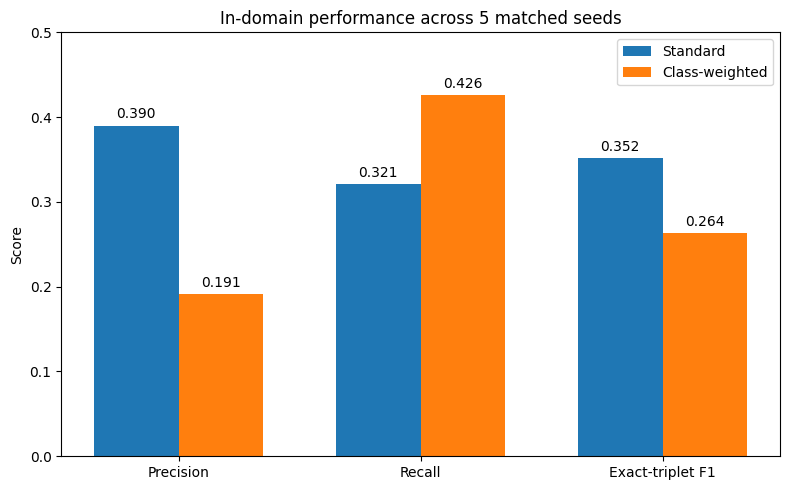

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = (
    indomain_df
    .groupby("model")[["precision", "recall", "f1"]]
    .mean()
    .loc[["standard", "weighted"]]
)

metrics = ["precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2,
    plot_data.loc["standard", metrics],
    width,
    label="Standard"
)

bars2 = ax.bar(
    x + width/2,
    plot_data.loc["weighted", metrics],
    width,
    label="Class-weighted"
)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "Exact-triplet F1"])
ax.set_ylabel("Score")
ax.set_title("In-domain performance across 5 matched seeds")
ax.set_ylim(0, 0.5)
ax.legend()

ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [49]:
presentation_lodo = coverage_vs_f1[
    ["unseen_category_pct", "lodo_f1"]
].copy()

presentation_lodo.columns = [
    "Unseen-category triplets (%)",
    "Exact-triplet F1"
]

presentation_lodo = presentation_lodo.round({
    "Unseen-category triplets (%)": 2,
    "Exact-triplet F1": 4
})

presentation_lodo

,Unseen-category triplets (%),Exact-triplet F1
domain,,
coursera,99.76,0.0000
food,72.29,0.0761
hotel,61.88,0.1644
laptop,100.00,0.0000
phone,100.00,0.0000
sight,100.00,0.0000


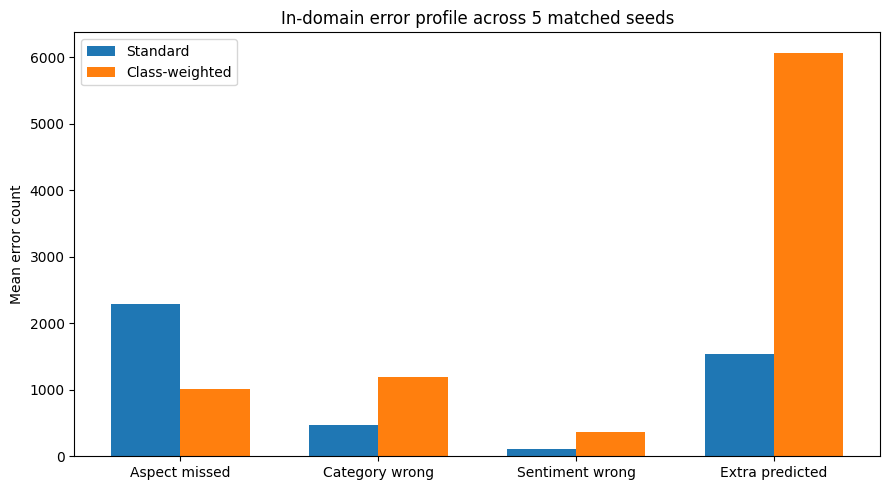

In [50]:
error_plot = error_summary.loc[
    ["standard", "weighted"],
    ["aspect_missed", "category_wrong",
     "sentiment_wrong", "extra_predicted"]
]

labels = [
    "Aspect missed",
    "Category wrong",
    "Sentiment wrong",
    "Extra predicted"
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2,
    error_plot.loc["standard"],
    width,
    label="Standard"
)

bars2 = ax.bar(
    x + width/2,
    error_plot.loc["weighted"],
    width,
    label="Class-weighted"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean error count")
ax.set_title("In-domain error profile across 5 matched seeds")
ax.legend()

plt.tight_layout()
plt.show()